In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from Bio import SeqIO

import SBM.utils.utils as ut

In [2]:
np.sum(np.load("../data/full_weights.npy"))

np.float32(25888.936)

# Shuffle columns in the alignment

We start with an alignment of only sector residues. These residues can be ranked by their **eigenvalue** on the sector's independent components, a value that can be extracted from libraries such as *cocoatree*.

In general, our goal is to reduce the number of parameters of the model we are trying to learn. This is a principle called **parsimony**. At the beginning, we have an alignment of 260 residues, each residue can take 21 symbols, and since we have a coupling matrix and a fields vector we would have
$$
N = (260 \times 21 \times 260 \times 21) + (260) = 2.98 \times 10^7
$$
which is a lot of parameters to learn, considering that our alignment has an effective number of sequences of
$$
p = 2.60 \times 10^4
$$
which gives us
$$
\alpha = \frac{p}{N} = 8.7 \times 10^{-4}
$$
which means we are in a strongly undersampled regime. Can we do better?

According to Halabi et al., 2009 specificity is a functional property which is nearly independently determined by a subset of residues called the **red sector**. It is defined by finding coevolutionarily nearly-independent components in residue space, and those residues who are substantially out of the bulk on one side (meaning: that coevolve substantially orthogonally to other groups of residues) can be considered to constitute a sector. In serine protease, for example, we can define the red sector (aka the specificity-determining sector) by choosing the nearly-independent group of sectors who contain the residues of the binding pocket, which is notably known to be crucial for specificity.

So since we want to learn the model in order to predict mutations that change our specificity, we can reduce ourselves to learning just the sector residues. The residues of the red sector in our alignment of serine proteases are 23, and again each residue can take 21 symbols. Then
$$
N_\text{red} = (23 \times 21 \times 23 \times 21) + (23) = 2.33 \times 10^5
$$
and
$$
p_\text{red} = 5.0 \times 10^3
$$
then
$$
\alpha_\text{red} = 2.1 \times 10^{-2}
$$

We have nearly gained three orders of magnitude! Our question is still: can we do better?

We can furtherly reduce the amount of parameters by starting to remove columns. We can start from the ones that are deemed less relevant to specificity (i.e. the ones that have a lower eigenvalue on the independent component of the red sector) and see if this influences an observable.

The observable of choice is the $\Delta\Delta E$ values for G226X mutations given a first D189S mutation.

In [3]:
model_root_folder = Path("../models/")

model_files = []

for model_folder in model_root_folder.glob("SectorShuffling_SubAln*"):
    # the name of model folders is composed by
    # 1. SectorShuffling
    # 2. SubAln + one digit # of subaln
    # 3. Step + two digits # of step
    # 4. Col + variable digits # of column OR noshuffle
    model_folder_name = model_folder.stem
    _, subaln_index, step_index, col_index = model_folder_name.split("_")
    subaln_index = int(subaln_index[-1:])
    step_index = int(step_index[-2:])
    if "Col" in col_index:
        col_index = int(col_index.replace("Col", ""))
    else:
        col_index = None

    # for each folder there is just one model
    model_file = list(model_folder.glob("*.npy"))[0]
    model_files.append({
        'subaln_index': subaln_index,
        'step_index': step_index,
        'col_index': col_index,
        'model_file': model_file
    })

df_models = pd.DataFrame(model_files)\
    .sort_values(["step_index", "subaln_index"])\
    .set_index(["step_index", "subaln_index"])

In [4]:
def compensatory_ddes(J, i = 11, j = 22, alpha = 3, beta = 16, gamma = 20):
    # This function returns as an output the values of DeltaDeltaE of
    # residue j going from amino acid gamma to delta
    # where z = {-, A, C, D, E, F, G, H, I, K, L, M, N, P, Q, R, S, T, V, W, Y}
    # given that i has been mutated from amino acid alpha to beta
    
    # we should compute the DeltaDeltaE for making the D189S mutation
    # and then computing the energies of mutations for position G226.
    # since in the sector definition G226 is in index 20, and D189 is
    # in index 11, we will change these indices. remember that the
    # indexing is res number, res number, aa number, aa number.

    delta = np.arange(21)    # all amino-acid indices

    DeltaDeltaE = ( J[i, j, alpha, delta] + J[i, j, beta, gamma]
                  - J[i, j, beta, delta] - J[i, j, alpha, gamma] )
    
    return DeltaDeltaE

Now we want to check that if we train a model with different subalignments, meaning alignments where we randomly pick some sequences with "ripescaggio". This would assay the robustness of our model against noise in the dataset. ???

In [6]:
df_models.loc[0]

,col_index,model_file
subaln_index,,
0,NaN,../models/SectorShuffling_SubAln0_Step00_noshu...
1,NaN,../models/SectorShuffling_SubAln1_Step00_noshu...
2,NaN,../models/SectorShuffling_SubAln2_Step00_noshu...
3,NaN,../models/SectorShuffling_SubAln3_Step00_noshu...
4,NaN,../models/SectorShuffling_SubAln4_Step00_noshu...
5,NaN,../models/SectorShuffling_SubAln5_Step00_noshu...
6,NaN,../models/SectorShuffling_SubAln6_Step00_noshu...
7,NaN,../models/SectorShuffling_SubAln7_Step00_noshu...
8,NaN,../models/SectorShuffling_SubAln8_Step00_noshu...


In [7]:
df_models

col_index  \
step_index subaln_index              
0          0                   NaN   
           1                   NaN   
           2                   NaN   
           3                   NaN   
           4                   NaN   
...                            ...   
22         5                 239.0   
           6                 239.0   
           7                 239.0   
           8                 239.0   
           9                 239.0   

                                                                model_file  
step_index subaln_index                                                     
0          0             ../models/SectorShuffling_SubAln0_Step00_noshu...  
           1             ../models/SectorShuffling_SubAln1_Step00_noshu...  
           2             ../models/SectorShuffling_SubAln2_Step00_noshu...  
           3             ../models/SectorShuffling_SubAln3_Step00_noshu...  
           4             ../models/SectorShuffling_SubAln4_Step00_noshu...  
...                                                                    ...  
22         5             ../models/SectorShuffling_SubAln5_Step22_Col23...  
           6             ../models/SectorShuffling_SubAln6_Step22_Col23...  
           7             ../models/SectorShuffling_SubAln7_Step22_Col23...  
           8             ../models/SectorShuffling_SubAln8_Step22_Col23...  
           9             ../models/SectorShuffling_SubAln9_Step22_Col23...  

[230 rows x 2 columns]

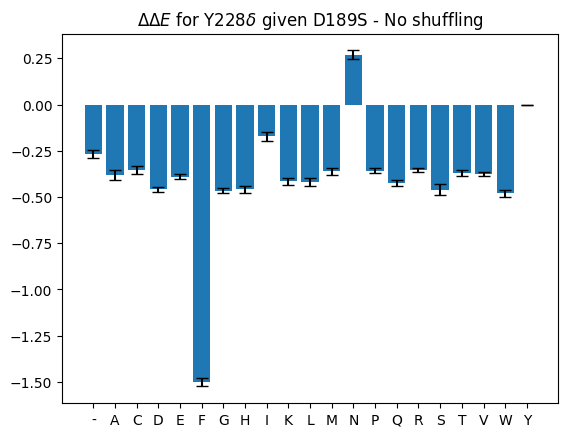

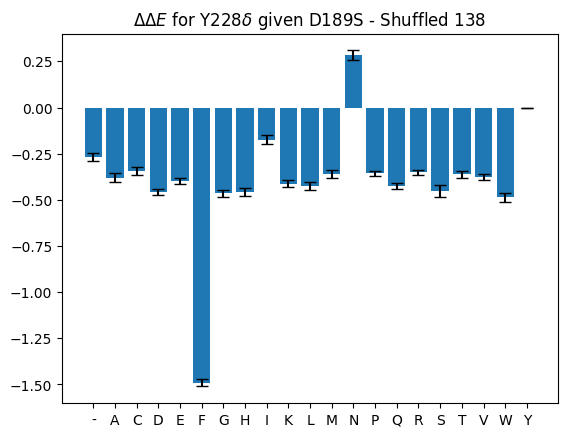

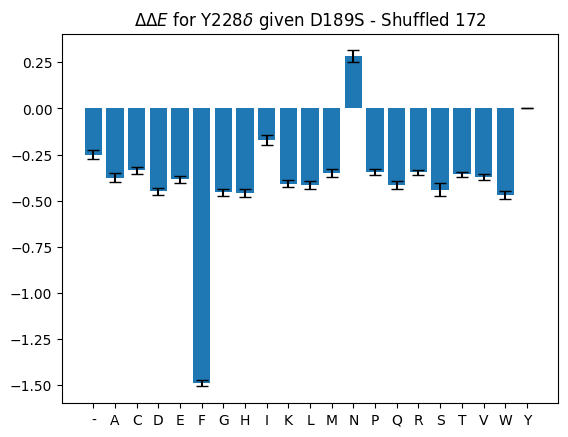

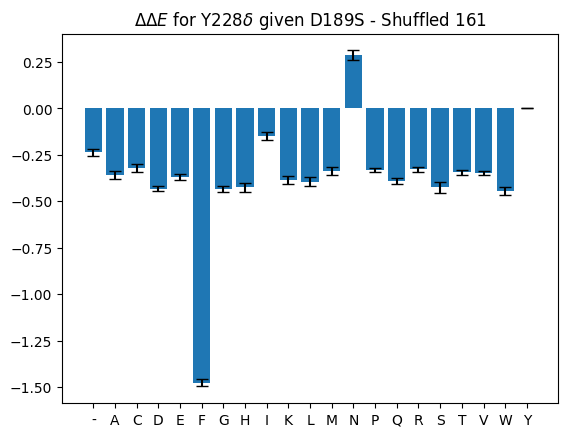

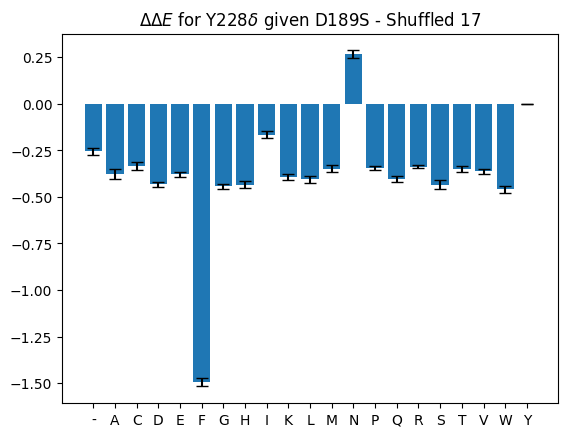

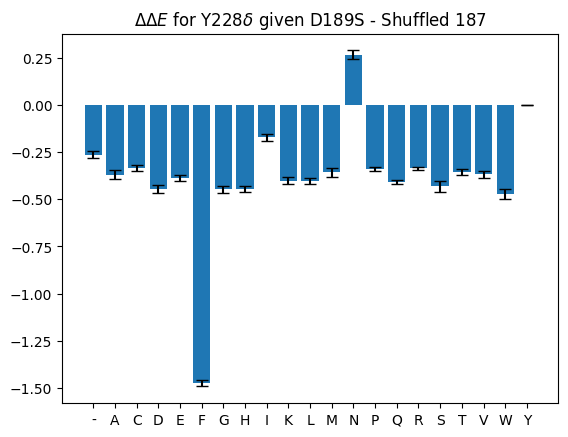

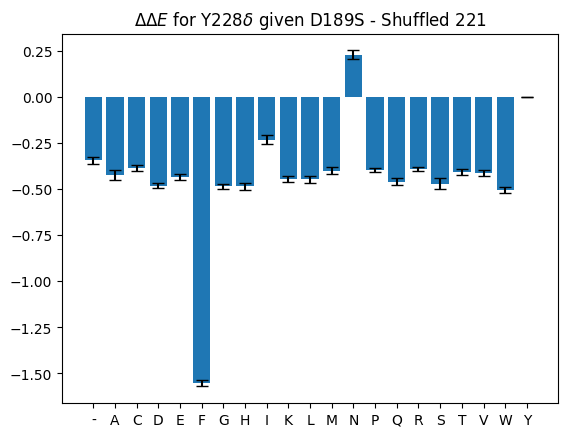

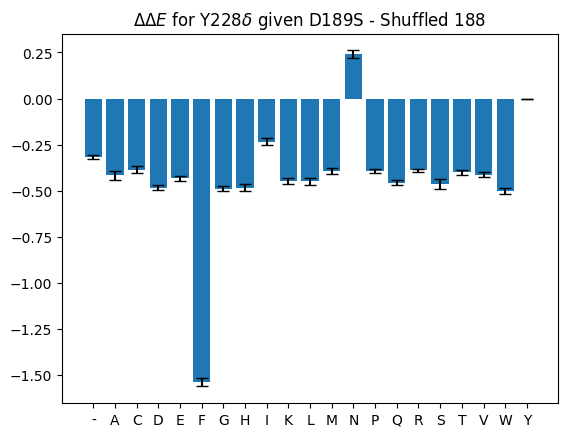

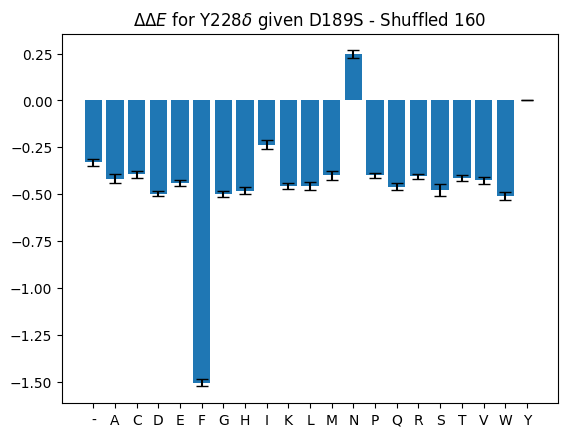

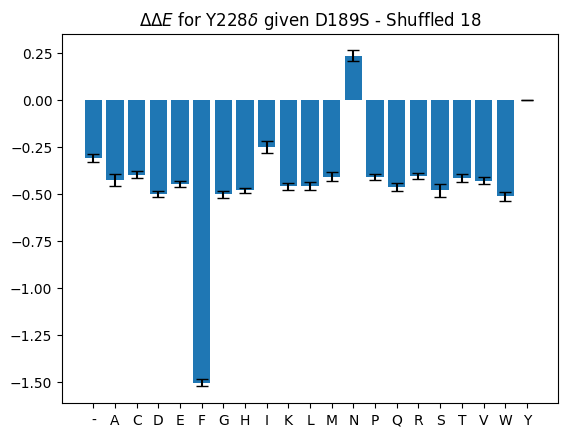

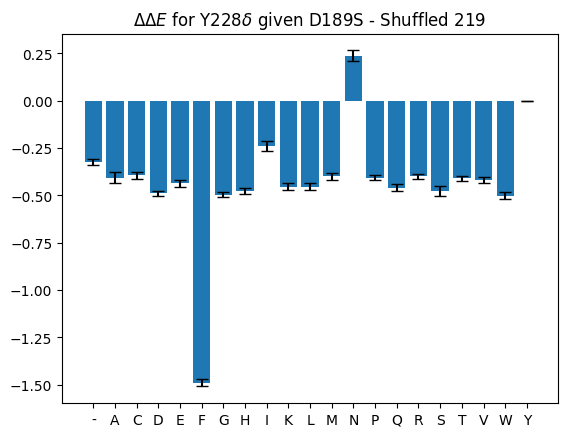

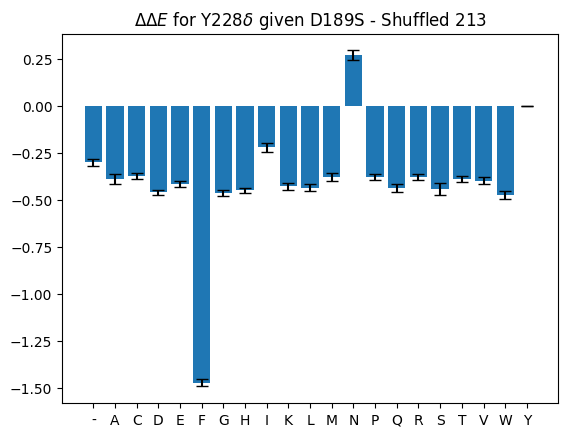

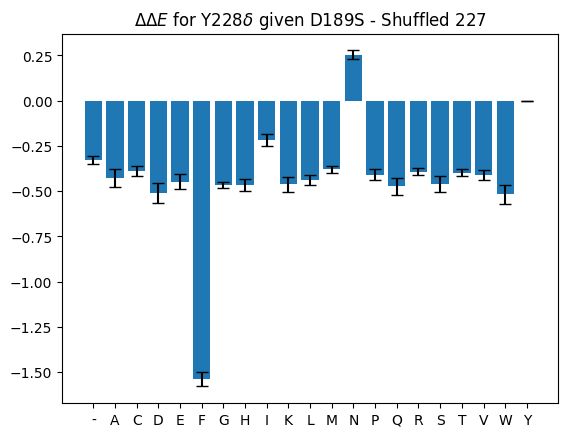

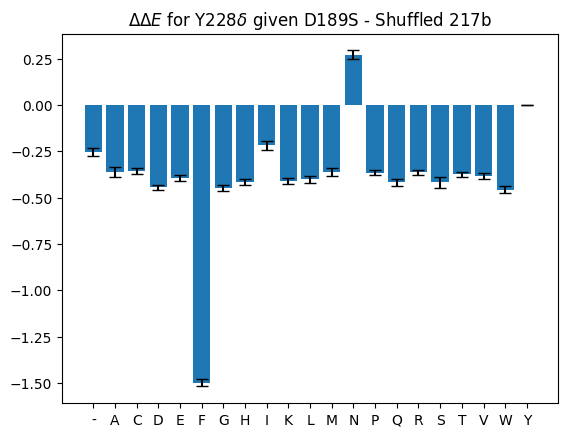

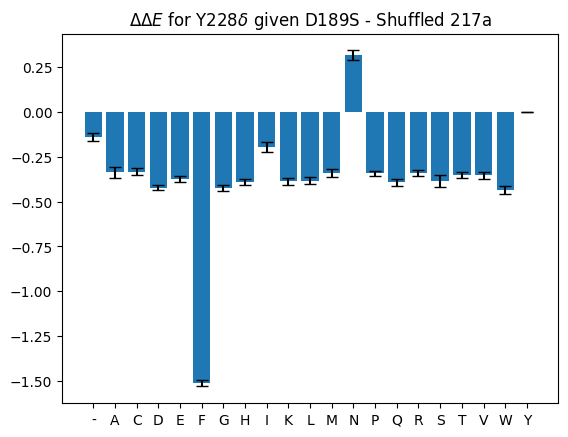

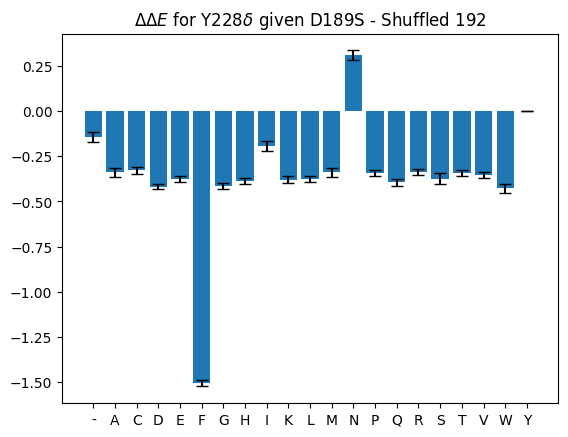

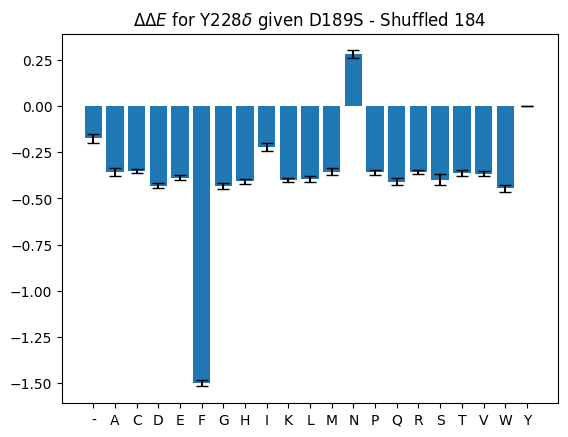

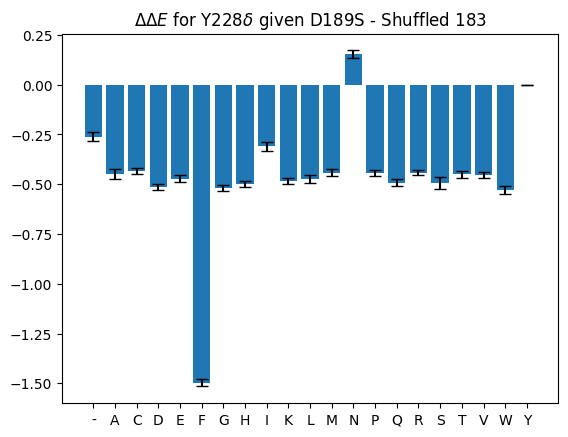

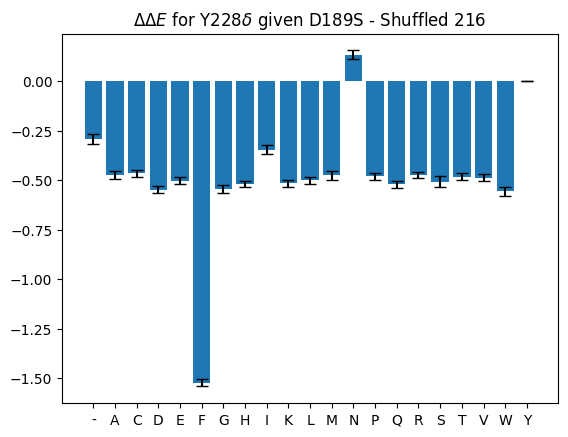

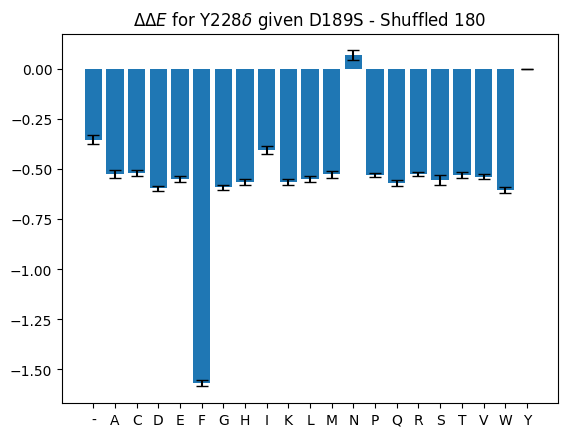

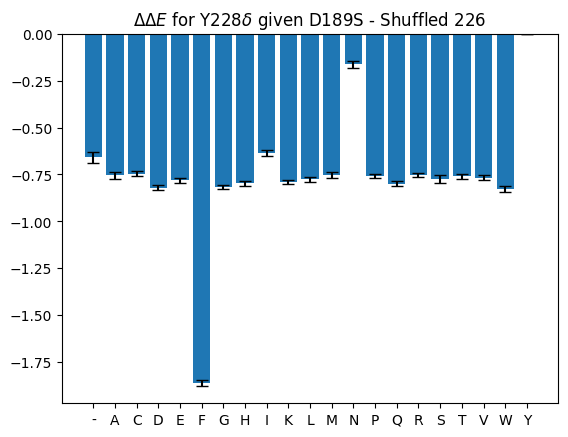

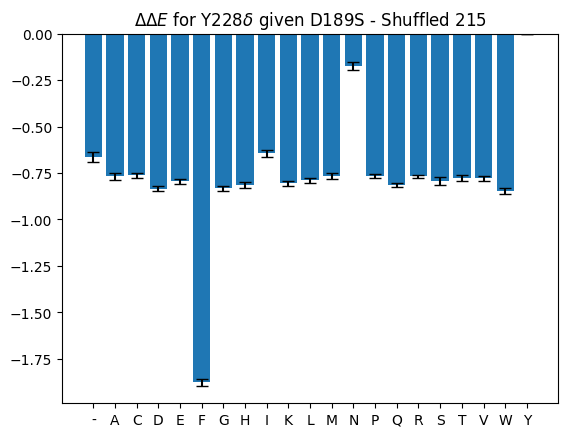

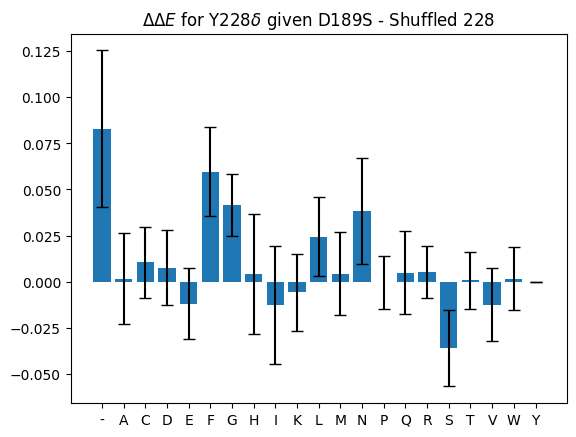

In [94]:
step_indices = df.index.get_level_values("step_index").unique()

for step_index in step_indices:
    comp_ddes_list = []
    for model_file in df_models.loc[step_index]["model_file"].values:
        model = np.load(model_file, allow_pickle=True).item()
        J, h = ut.Zero_Sum_Gauge(model["J"], model["h"])
        comp_ddes = (compensatory_ddes(J, i = 11, j = 22, alpha = 3, beta = 16, gamma = 20).ravel())
        comp_ddes_list.append(comp_ddes)
    fig = plt.figure()
    plt.bar(
        np.arange(21),
        np.mean(comp_ddes_list, axis=0),
        yerr=np.std(comp_ddes_list, axis=0) / np.sqrt(len(comp_ddes_list)),
        capsize=4
    )
    col_index = df_models.loc[step_index]["col_index"][0]
    if np.isnan(col_index):
        shuffled_column_string = "No shuffling"
    else:
        col_index = int(col_index)
        shuffled_column_string = f"Shuffled {nums[col_index]}"
    plt.title(fr"$\Delta \Delta E$ for Y228$\delta$ given D189S - {shuffled_column_string}")
    plt.xticks(ticks=np.arange(21), labels="-ACDEFGHIKLMNPQRSTVWY")
    plt.show()

In [8]:
def Zero_Sum_Gauge(J,h):
	"""
	Function to apply a zero-sum gauge transformation to J and h matrices.
	"""
	if J is None:
		L,q = h.shape
		J = np.zeros((L,L,q,q))
		h_zg = np.copy(h)
		h_zg -= np.expand_dims(np.mean(h,axis = 1),axis = 1) 
		h_zg += np.sum(np.mean(J,axis=3)-np.expand_dims(np.mean(J,axis=(2,3)),axis=2),axis=1)
		return None,h_zg
	
	if h is None:
		L,q = J.shape[0],J.shape[2]
		J_zg = np.copy(J)
		J_zg -= np.expand_dims(np.mean(J,axis = 2),axis = 2) 
		J_zg -= np.expand_dims(np.mean(J,axis=3),axis =3) 
		J_zg += np.expand_dims(np.mean(J,axis=(2,3)),axis=(2,3))
		return J_zg, None

	J_zg = np.copy(J)
	h_zg = np.copy(h)

	h_zg -= np.expand_dims(np.mean(h,axis = 1),axis = 1) 
	h_zg += np.sum(np.mean(J,axis=3)-np.expand_dims(np.mean(J,axis=(2,3)),axis=2),axis=1)

	J_zg -= np.expand_dims(np.mean(J,axis = 2),axis = 2) 
	J_zg -= np.expand_dims(np.mean(J,axis=3),axis =3) 
	J_zg += np.expand_dims(np.mean(J,axis=(2,3)),axis=(2,3))

	return J_zg, h_zg

def Mutational_effect(WT_seq,h,J):
	"""
	Function to compute mutational effects based on the provided wild-type sequence, h, and J values, 
	considering the changes in energy resulting from single amino acid substitutions.
	"""
	L,q = h.shape
	Mut = np.zeros((q,L))
	for k in range(L):
		for b in range(q):
			if b != WT_seq[k]:
				Delta_E = h[k,WT_seq[k]] - h[k,b] - np.sum(J[k,np.arange(L),b,WT_seq]) + np.sum(J[k,np.arange(L),WT_seq[k],WT_seq]) 
				Mut[b,k] = Delta_E
	return Mut

def next_mutation(J, h, seq_wt, pinned_mutations):
    """
    Propose next mutation using the same logic as Propose_Mutation_DDE2,
    but only with raw array indices (no reference-position mapping).

    Parameters
    ----------
    J, h : model parameters
        Same objects used by ut.Mutational_effect.
    seq_wt : np.ndarray, shape (L,)
        WT sequence encoded as AA indices (0..q-1).
    pinned_mutations : list of (mut_aa_idx, site_idx)
        Example after D189S and Y228F (in your array indexing):
        [(16, i_D189), (5, i_Y228)]  # if S=16, F=5 in your alphabet.

    Returns
    -------
    next_mut : tuple (aa_idx, site_idx, score)
        Best next mutation (global minimum of Mut_diff after masking pinned sites).
    mut_diff : np.ndarray
        Full matrix Mut_pred(seq_cur) - Mut_pred(seq_wt), masked at pinned sites.
    seq_cur : np.ndarray
        Sequence with pinned mutations applied.
    """
    # Build current sequence with pinned mutations
    seq_cur = np.array(seq_wt, copy=True)
    for mut_aa_idx, site_idx in pinned_mutations:
        seq_cur[site_idx] = mut_aa_idx

    # Same baseline as Propose_Mutation_DDE2
    mut_pred_wt = Mutational_effect(seq_wt, h, J)
    mut_pred_cur = Mutational_effect(seq_cur, h, J)
    mut_diff = mut_pred_cur - mut_pred_wt

    # Mask already mutated sites (same behavior)
    for _, site_idx in pinned_mutations:
        mut_diff[:, site_idx] = np.nan

    # Pick global minimum
    aa_idx, site_idx = np.unravel_index(np.nanargmin(mut_diff), mut_diff.shape)
    score = float(mut_diff[aa_idx, site_idx])

    return (int(aa_idx), int(site_idx), score), mut_diff, seq_cur

In [9]:
def compensatory_ddes_k(J, target_site, target_ref_aa, pinned_mutations, q=21):
    """
    Compute compensatory DeltaDeltaE at one target site for all amino acids b.

    Parameters
    ----------
    J : np.ndarray
        Couplings with shape [L, L, q, q].
    target_site : int
        Site j where you scan amino acids b.
    target_ref_aa : int
        Baseline aa index y at target_site.
    pinned_mutations : list[tuple[int, int, int]]
        List of (site_i, wt_aa_x, mut_aa_m), one per pinned mutation.
    q : int
        Alphabet size (default 21).

    Returns
    -------
    np.ndarray
        DeltaDeltaE vector of shape (q,), one value per b.
    """
    b = np.arange(q)
    y = target_ref_aa

    dde = np.zeros(q, dtype=float)
    for i, x, m in pinned_mutations:
        dde += (
            J[i, target_site, x, b]
            + J[i, target_site, m, y]
            - J[i, target_site, m, b]
            - J[i, target_site, x, y]
        )
    return dde

In [10]:
alphabet = "-ACDEFGHIKLMNPQRSTVWY"
AA_2_NUM = {aa: i for i, aa in enumerate(alphabet)}
nums_redsector = ['17', '18', '138', '160', '161', '172', '180', '183', '184', '187',
       '188', '189', '192', '213', '215', '216', '217a', '217b', '219',
       '221', '226', '227', '228']

In [129]:
seq_wt_trypsin = 'VGIAPYMVGGGDQVWG--GAGVY'
seq_wt_trypsin_num = np.array([AA_2_NUM[a] for a in seq_wt_trypsin], dtype=int)

for model_file in df_models.loc[0]["model_file"].values:
    model = np.load(model_file, allow_pickle=True).item()
    J, h = Zero_Sum_Gauge(model["J"], model["h"])
    (proposed_aa, proposed_site, score), _, _ = next_mutation(J, h, seq_wt_trypsin_num, [
        (16, 11),
        (5, 22)
    ])
    print(alphabet[proposed_aa], proposed_site, nums_redsector[proposed_site], score)

V 20 226 -3.1365976099264903
Q 20 226 -3.369154367125894
Q 20 226 -3.26835211319208
Q 20 226 -3.3345514549104567
V 20 226 -2.9404494858528056
Q 20 226 -3.6480542834736207
Q 20 226 -3.327050082330512
Q 20 226 -3.3249117732908635
M 20 226 -3.198350744343194
Q 20 226 -3.057309261986111


In [130]:
AA_2_NUM[seq_wt_trypsin[20]]

6

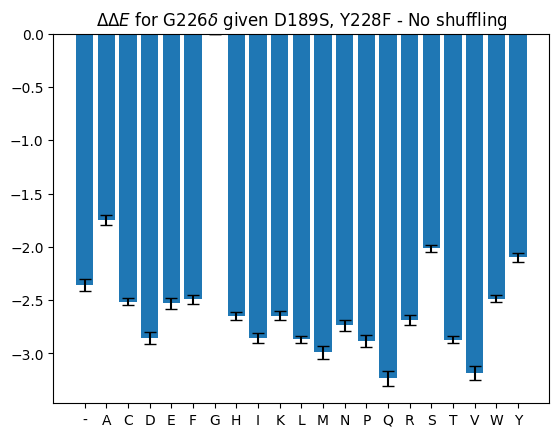

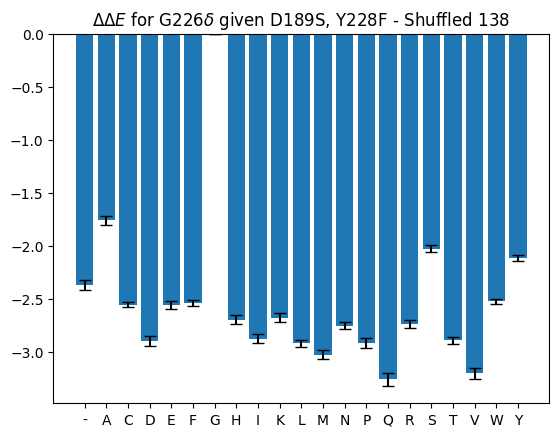

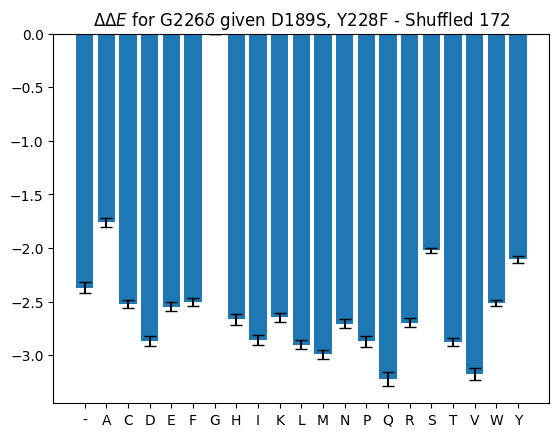

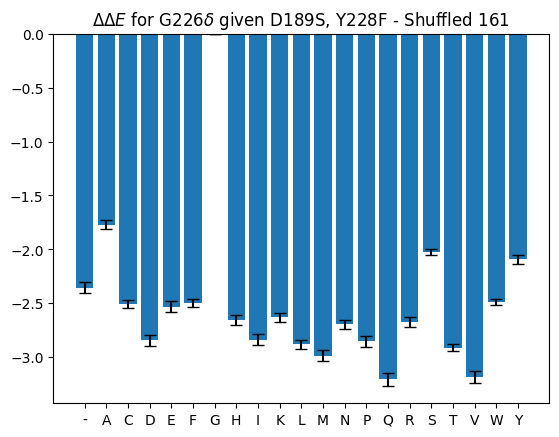

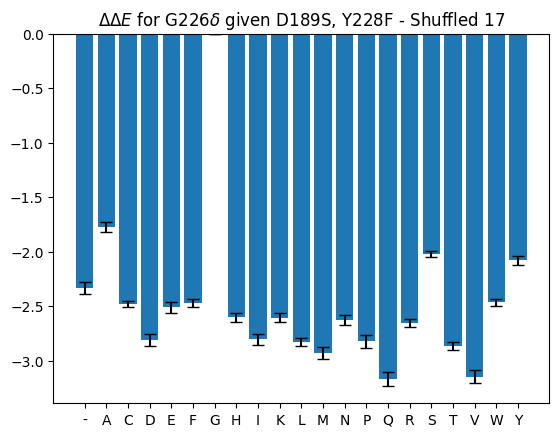

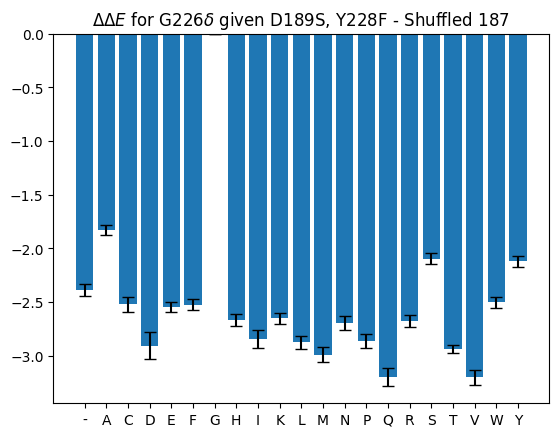

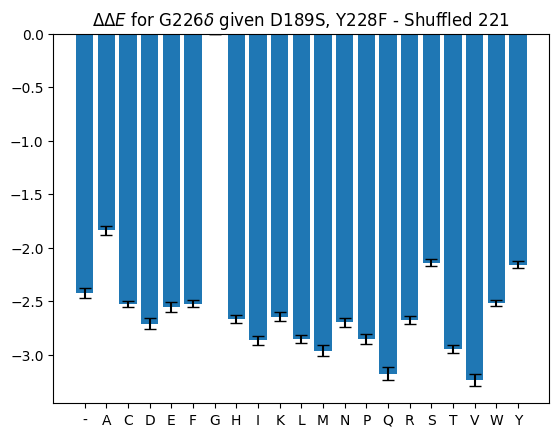

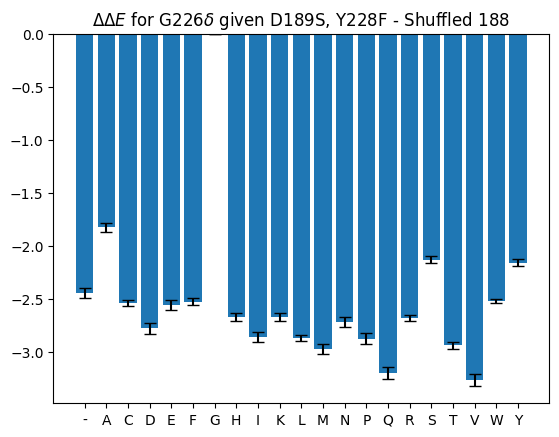

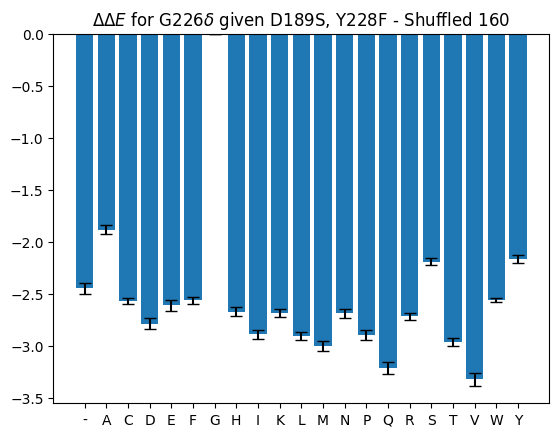

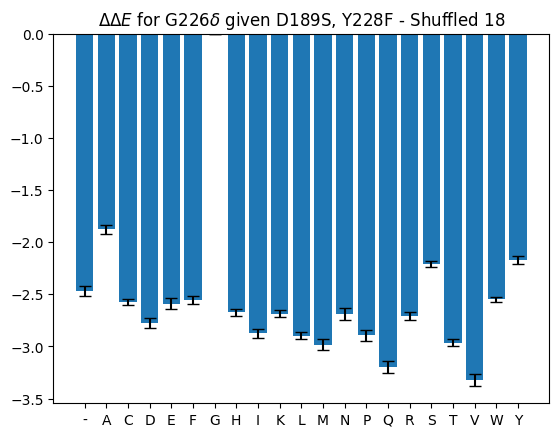

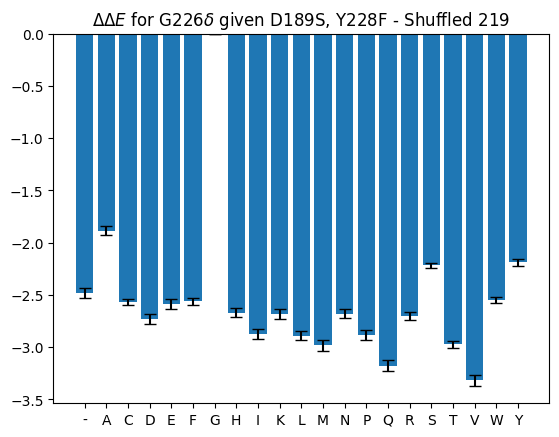

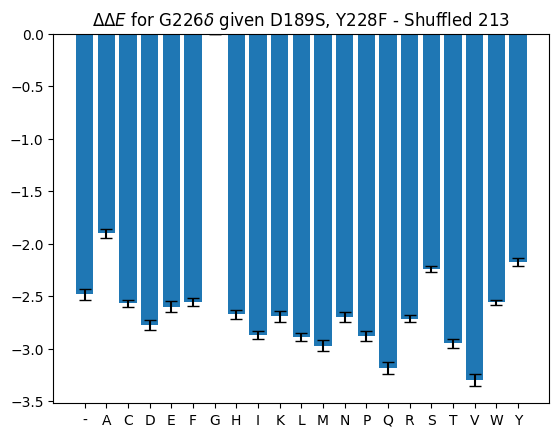

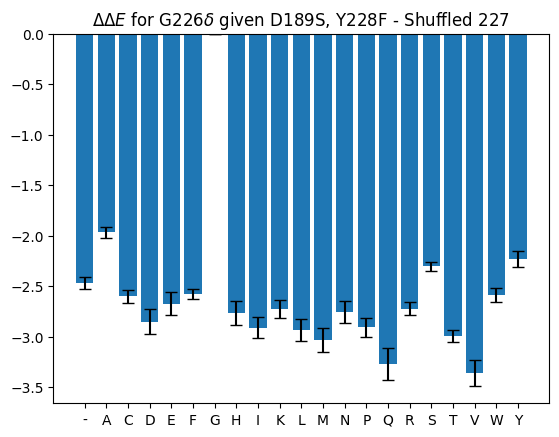

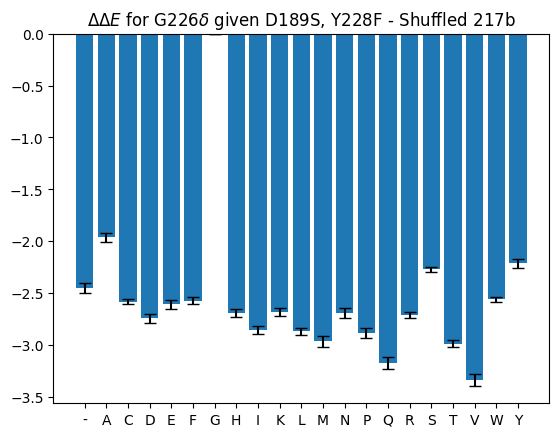

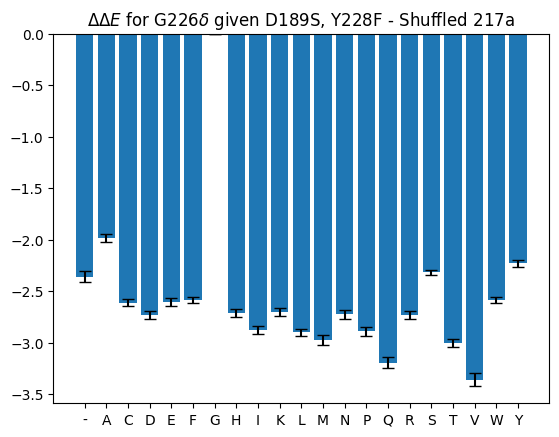

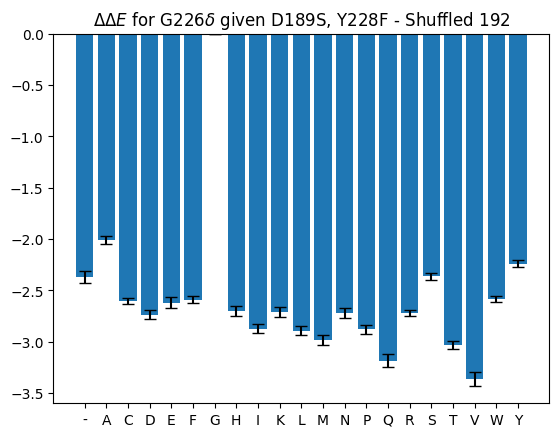

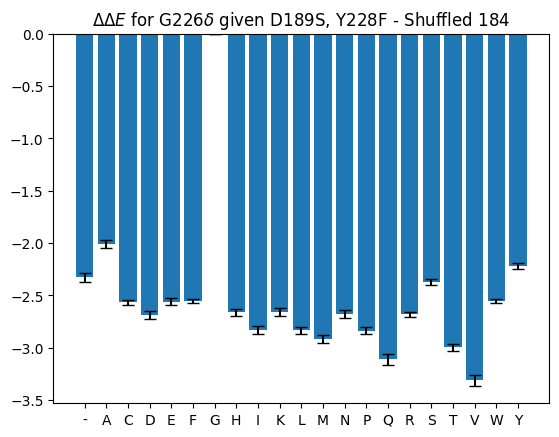

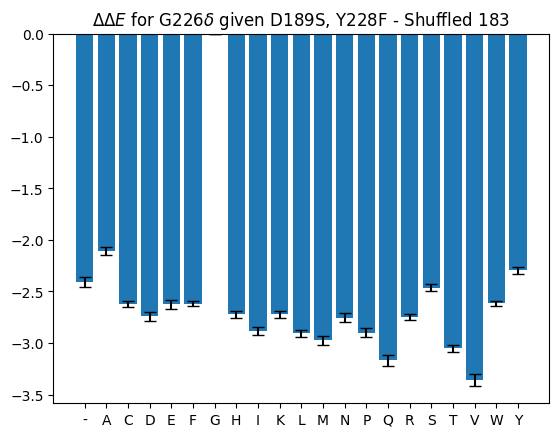

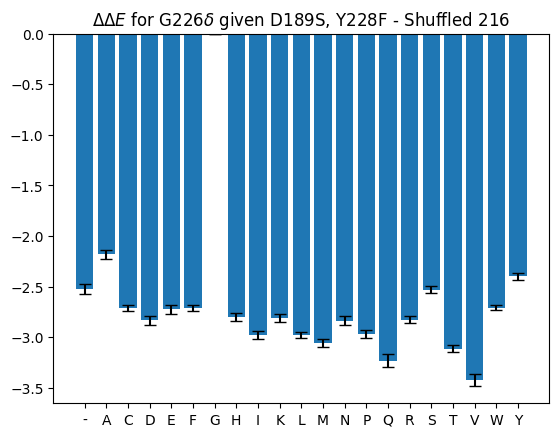

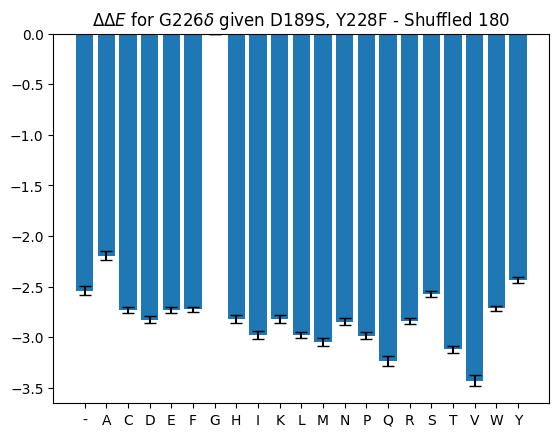

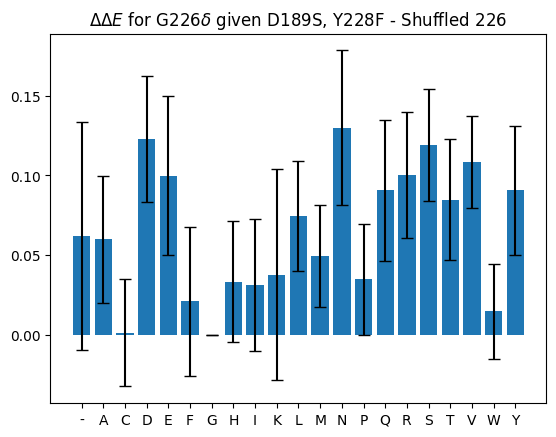

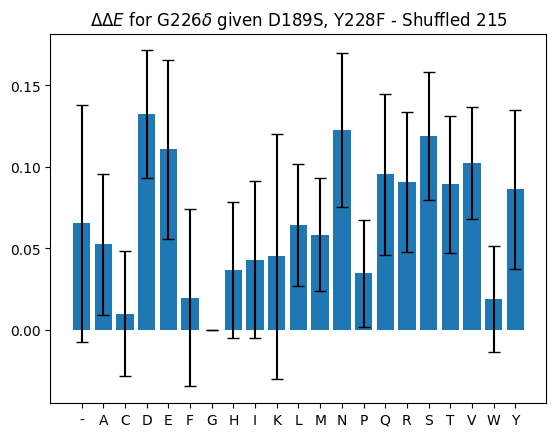

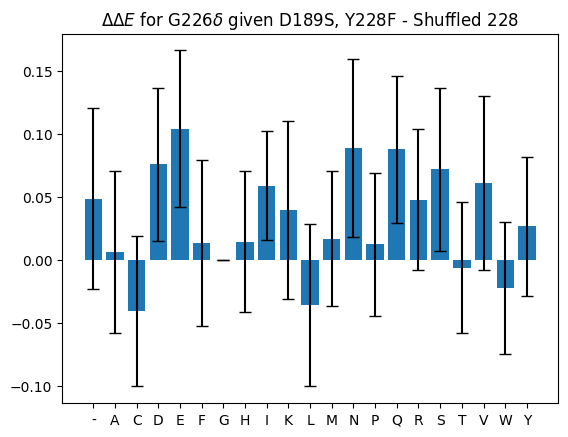

In [131]:
step_indices = df.index.get_level_values("step_index").unique()

for step_index in step_indices:
    comp_ddes_list = []
    for model_file in df_models.loc[step_index]["model_file"].values:
        model = np.load(model_file, allow_pickle=True).item()
        J, h = Zero_Sum_Gauge(model["J"], model["h"])
        comp_ddes = compensatory_ddes_k(J, 20, 6, [
            (11, 3, 16),
            (22, 20, 5)
        ], q=21)\
        .ravel()
        comp_ddes_list.append(comp_ddes)
    fig = plt.figure()
    plt.bar(
        np.arange(21),
        np.mean(comp_ddes_list, axis=0),
        yerr=np.std(comp_ddes_list, axis=0) / np.sqrt(len(comp_ddes_list)),
        capsize=4
    )
    col_index = df_models.loc[step_index]["col_index"][0]
    if np.isnan(col_index):
        shuffled_column_string = "No shuffling"
    else:
        col_index = int(col_index)
        shuffled_column_string = f"Shuffled {nums[col_index]}"
    plt.title(fr"$\Delta \Delta E$ for G226$\delta$ given D189S, Y228F - {shuffled_column_string}")
    plt.xticks(ticks=np.arange(21), labels="-ACDEFGHIKLMNPQRSTVWY")
    plt.show()

In [132]:
seq_wt_trypsin = 'VGIAPYMVGGGDQVWG--GAGVY'
seq_wt_trypsin_num = np.array([AA_2_NUM[a] for a in seq_wt_trypsin], dtype=int)

for model_file in df_models.loc[0]["model_file"].values:
    model = np.load(model_file, allow_pickle=True).item()
    J, h = Zero_Sum_Gauge(model["J"], model["h"])
    (proposed_aa, proposed_site, score), _, _ = next_mutation(J, h, seq_wt_trypsin_num, [
        (16, 11),
        (5, 22),
        (18, 20)
    ])
    print(alphabet[proposed_aa], proposed_site, nums_redsector[proposed_site], score)

E 19 221 -2.487746011098893
E 19 221 -2.288905092882444
D 19 221 -2.22838895677899
E 19 221 -2.6805273654837114
D 19 221 -2.403019930978233
E 19 221 -2.31294408974757
D 19 221 -2.158005210091267
E 19 221 -2.4416010433844137
E 19 221 -2.5694369874531855
D 19 221 -1.980784026011031


In [133]:
AA_2_NUM[seq_wt_trypsin[20]]

6

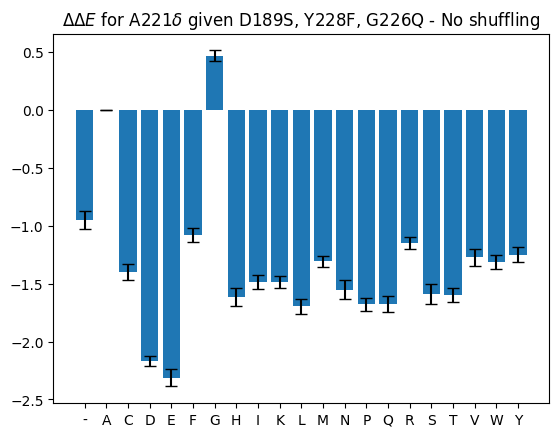

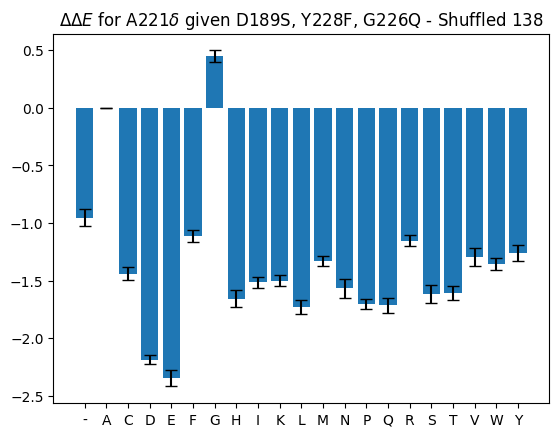

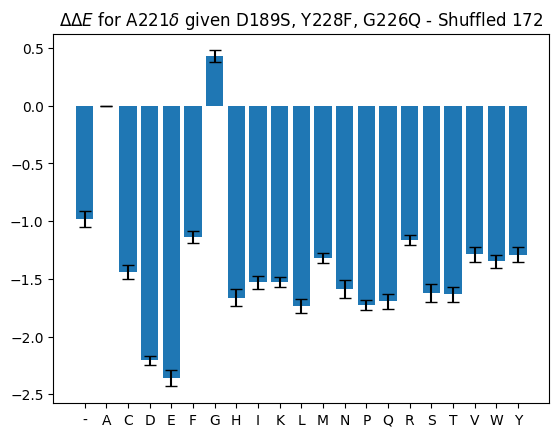

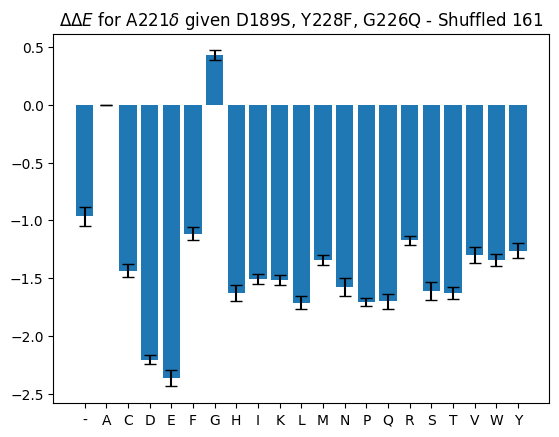

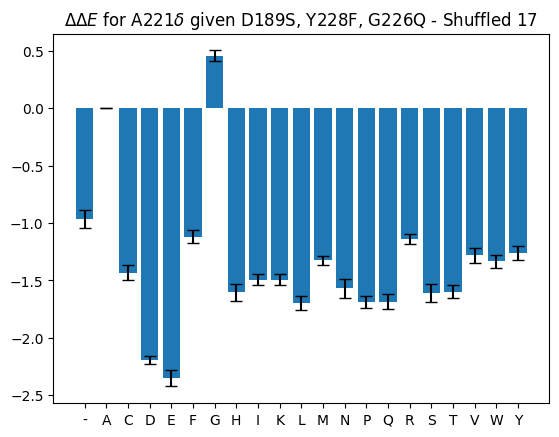

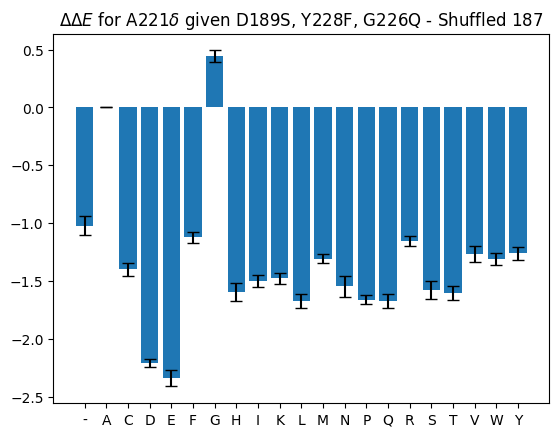

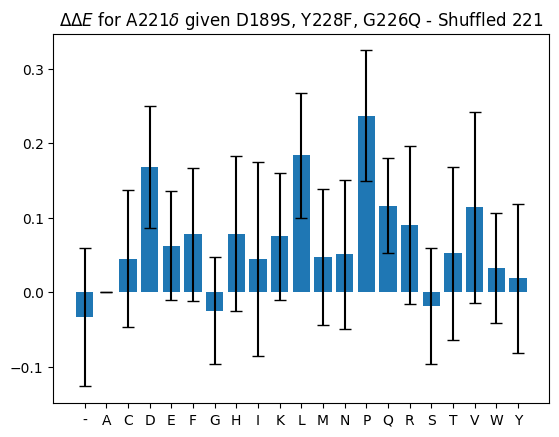

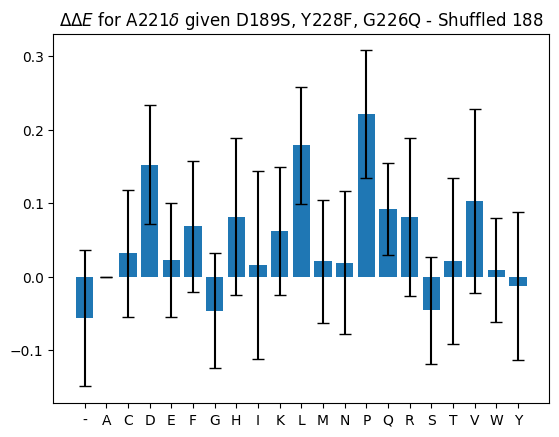

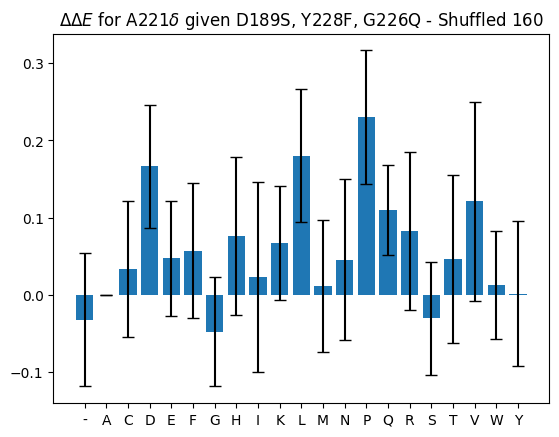

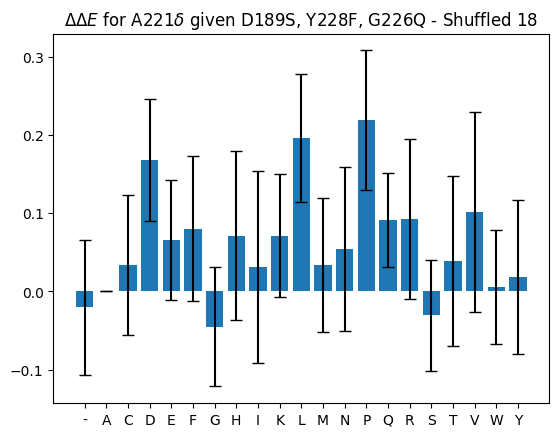

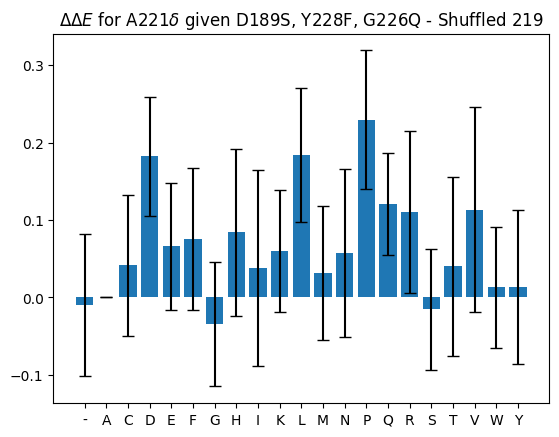

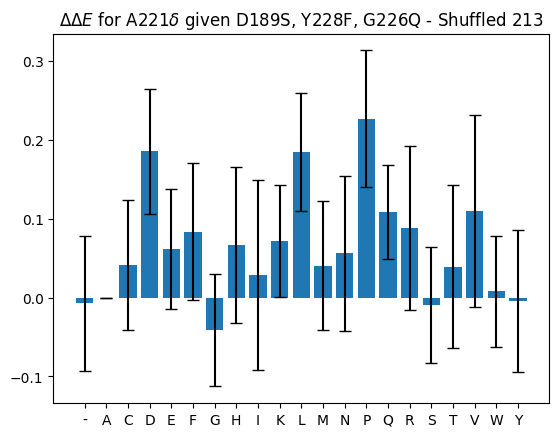

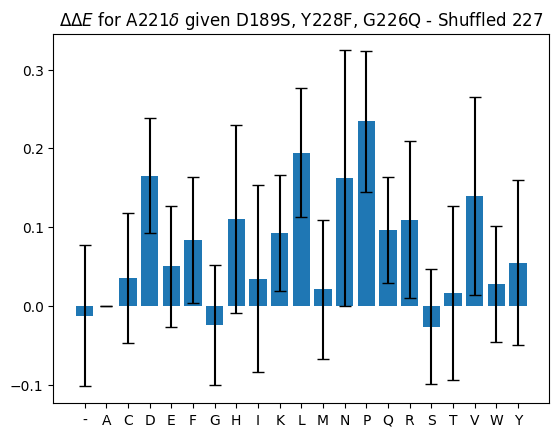

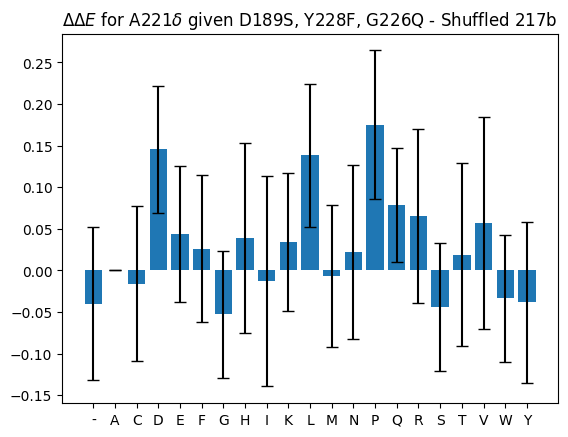

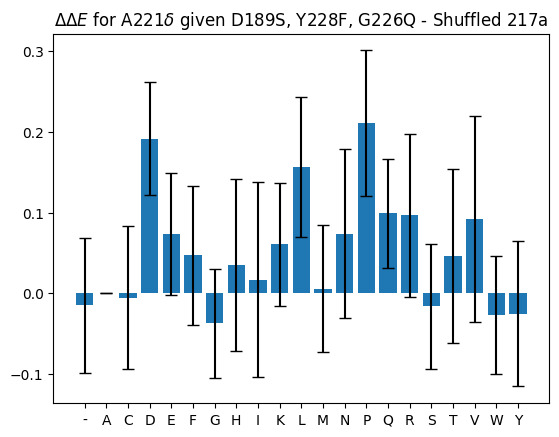

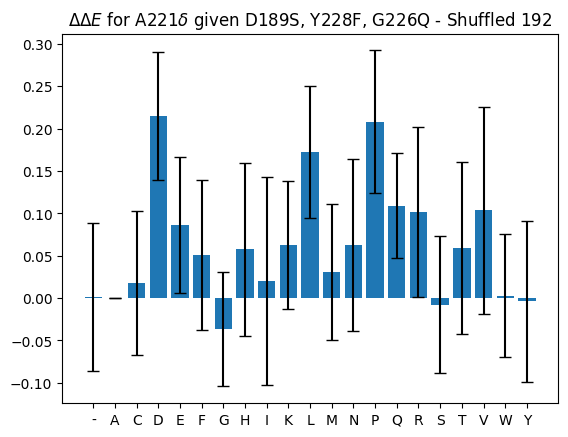

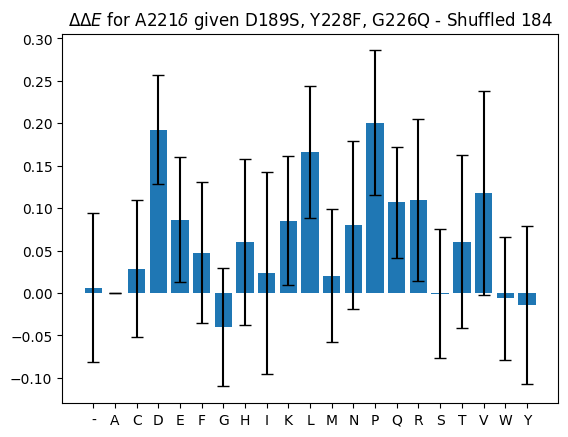

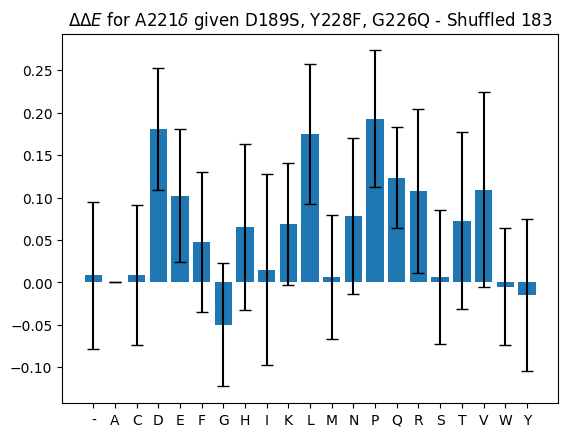

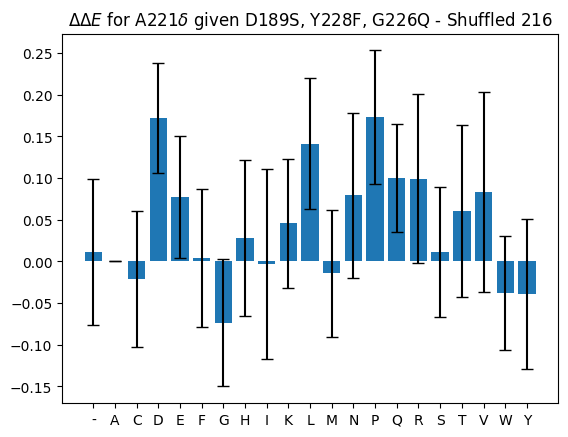

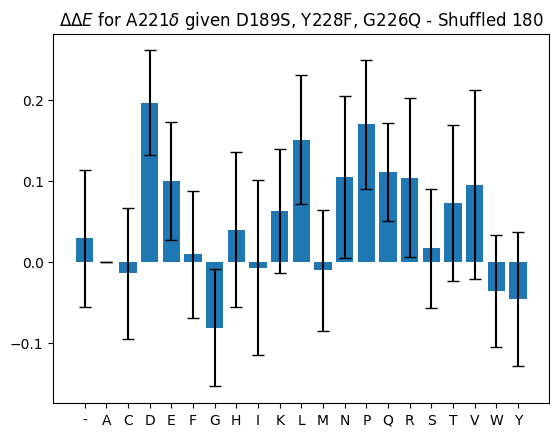

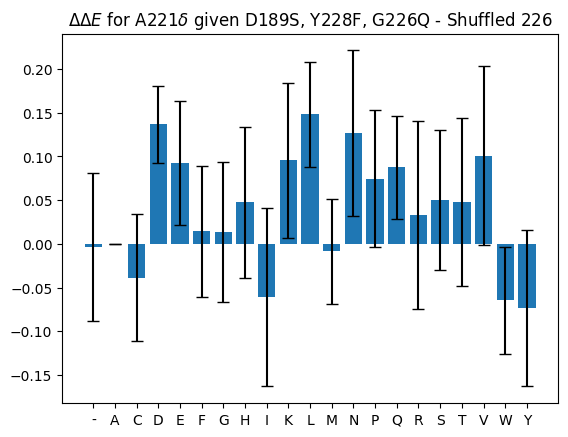

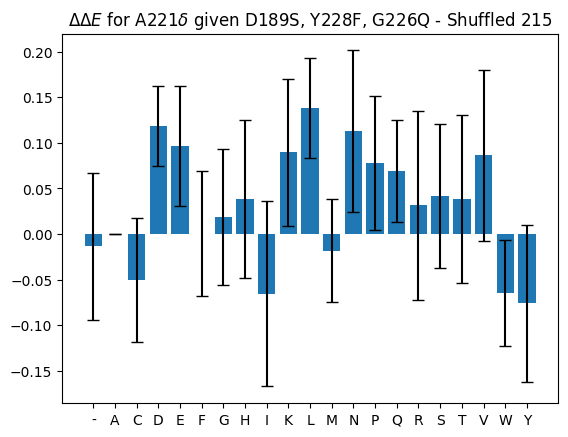

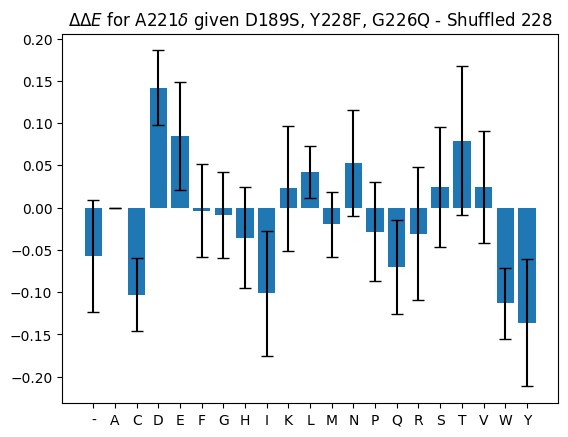

In [134]:
step_indices = df.index.get_level_values("step_index").unique()

for step_index in step_indices:
    comp_ddes_list = []
    for model_file in df_models.loc[step_index]["model_file"].values:
        model = np.load(model_file, allow_pickle=True).item()
        J, h = Zero_Sum_Gauge(model["J"], model["h"])
        comp_ddes = compensatory_ddes_k(J, 19, 1, [
            (11, 3, 16),
            (22, 20, 5),
            (20, 6, 18)
        ], q=21)\
        .ravel()
        comp_ddes_list.append(comp_ddes)
    fig = plt.figure()
    plt.bar(
        np.arange(21),
        np.mean(comp_ddes_list, axis=0),
        yerr=np.std(comp_ddes_list, axis=0) / np.sqrt(len(comp_ddes_list)),
        capsize=4
    )
    col_index = df_models.loc[step_index]["col_index"][0]
    if np.isnan(col_index):
        shuffled_column_string = "No shuffling"
    else:
        col_index = int(col_index)
        shuffled_column_string = f"Shuffled {nums[col_index]}"
    plt.title(fr"$\Delta \Delta E$ for A221$\delta$ given D189S, Y228F, G226Q - {shuffled_column_string}")
    plt.xticks(ticks=np.arange(21), labels="-ACDEFGHIKLMNPQRSTVWY")
    plt.show()

In [11]:
nums = np.array(['16', '17', '18', '19', '20', '21', '22', '23', '24', '25', '26', '27', '28', '29', '30', '31', '32', '33', '34', '37', '37a', '37b', '37c', '37d', '37e', '38', '39', '40', '41', '42', '43', '44', '45', '46', '47', '48', '49', '50', '51', '52', '53', '54', '55', '56', '57', '58', '59', '60', '61', '61a', '61b', '61c', '61d', '61e', '61f', '61g', '62', '63', '64', '66', '67', '68', '69', '70', '71', '72', '73', '74', '74a', '75', '76', '77', '78', '79', '80', '81', '82', '83', '84', '85', '86', '87', '88', '89', '90', '91', '92', '93', '94', '95', '96', '96a', '96b', '97', '98', '99', '100', '101', '102', '103', '104', '105', '106', '107', '108', '109', '110', '111', '112', '113', '114', '115', '116', '117', '118', '119', '120', '121', '121a', '122', '123', '124', '125', '125a', '125b', '125c', '127', '128', '129', '130', '130a', '132', '133', '133a', '134', '135', '136', '137', '138', '139', '140', '141', '142', '143', '144', '145', '146', '147', '148', '148a', '148b', '148c', '148d', '149', '150', '151', '152', '153', '154', '155', '156', '157', '158', '159', '160', '161', '162', '163', '164', '165', '166', '167', '168', '169', '170', '171', '172', '173', '173a', '173b', '174', '175', '176', '177', '178', '179', '180', '181', '182', '183', '184', '184A', '185', '186', '187', '188', '188A', '189', '190', '191', '192', '193', '194', '195', '196', '197', '198', '199', '200', '201', '202', '202a', '202b', '202c', '202d', '202e', '203', '204', '209', '210', '211', '212', '213', '214', '215', '216', '217', '217a', '217b', '219', '220', '221', '221A', '222', '223', '224', '225', '226', '227', '228', '229', '230', '231', '232', '233', '234', '235', '236', '237', '238', '239', '240', '241', '242', '243', '244', '245', '245a', '245b', '245c'])
alphabet = "-ACDEFGHIKLMNPQRSTVWY"

In [16]:
descs, seqs = [], []
for record in SeqIO.parse("../data/iter_aln_dedup_sp.faa", "fasta"):
    descs.append(record.description)
    seqs.append([c for c in record.seq])

descs_arr = np.array(descs)
seqs_arr = np.array(seqs)

idx = np.where(np.char.find(descs_arr, "CTRA_BOVIN") != -1)[0][0]
seq = seqs_arr[idx]

sorted_redsector_index = np.sort(np.load("../data/red_sector_indices.npy"))
print(seq)
print(seq[sorted_redsector_index])
print(nums[sorted_redsector_index])
print(list(enumerate(zip(seq[sorted_redsector_index], nums[sorted_redsector_index]))))

['I' 'V' 'N' 'G' 'E' 'E' 'A' 'V' 'P' 'G' 'S' 'W' 'P' 'W' 'Q' 'V' 'S' 'L'
 'Q' 'D' 'K' '-' '-' '-' 'T' 'G' 'F' 'H' 'F' 'C' 'G' 'G' 'S' 'L' 'I' 'N'
 'E' 'N' 'W' 'V' 'V' 'T' 'A' 'A' 'H' 'C' 'G' 'V' 'T' '-' '-' '-' '-' '-'
 '-' 'T' 'S' 'D' 'V' 'V' 'V' 'A' 'G' 'E' 'F' 'D' 'Q' 'G' '-' 'S' 'S' 'S'
 'E' 'K' 'I' 'Q' 'K' 'L' 'K' 'I' 'A' 'K' 'V' 'F' 'K' 'N' 'S' 'K' 'Y' 'N'
 'S' '-' '-' 'L' 'T' 'I' 'N' 'N' 'D' 'I' 'T' 'L' 'L' 'K' 'L' 'S' 'T' 'A'
 'A' 'S' 'F' 'S' 'Q' 'T' 'V' 'S' 'A' 'V' 'C' '-' 'L' 'P' 'S' 'A' 'S' '-'
 '-' 'D' 'D' 'F' 'A' 'A' 'G' '-' 'T' 'T' 'C' 'V' 'T' 'T' 'G' 'W' 'G' 'L'
 'T' '-' 'R' 'Y' '-' '-' 'T' 'N' 'A' '-' 'N' 'T' 'P' 'D' 'R' 'L' 'Q' 'Q'
 'A' 'S' 'L' 'P' 'L' 'L' 'S' 'N' 'T' 'N' 'C' 'K' 'K' 'Y' 'W' 'G' '-' '-'
 'T' 'K' 'I' 'K' 'D' 'A' 'M' 'I' 'C' 'A' 'G' 'A' 'S' 'G' 'V' '-' '-' 'S'
 'S' 'C' 'M' 'G' 'D' 'S' 'G' 'G' 'P' 'L' 'V' 'C' 'K' 'K' 'N' '-' 'G' 'A'
 'W' 'T' 'L' 'V' 'G' 'I' 'V' 'S' 'W' 'G' 'S' 'S' '-' 'T' 'C' 'S' 'T' 'S'
 '-' 'T' 'P' 'G' 'V' 'Y' 'A' 'R' 'V' 'T' 'A' 'L' 'V

In [17]:
''.join(seq[sorted_redsector_index])

'VNTLPWMAGV-SMVWGS-TSGVY'

In [14]:
nums[sorted_redsector_index]

array(['17', '18', '138', '160', '161', '172', '180', '183', '184', '187',
       '188', '189', '192', '213', '215', '216', '217a', '217b', '219',
       '221', '226', '227', '228'], dtype='<U4')

In [15]:
def compensatory_ddes(J):
    # we should compute the DeltaDeltaE for making the D189S mutation
    # and then computing the energies of mutations for position G226.
    # since in the sector definition G226 is in index 20, and D189 is
    # in index 11, we will change these indices. remember that the
    # indexing is res number, res number, aa number, aa number.
    i, j = 11, 20
    x, m, y = 3, 16, 6   # D, S, G

    b = np.arange(21)    # all amino-acid indices

    DeltaDeltaE = ( J[i, j, x, b] + J[i, j, m, y]
                  - J[i, j, m, b] - J[i, j, x, y] )
    return DeltaDeltaE

We do not need to unpack each 10 runs, we just need the average J.

So for each step_index, we can do the prediction of the G226x mutation and compute the average and the std over the different subalignments.

In [19]:
comp_ddes_list = []
for model_file in df.loc[0].values[:, 0]:
    model = np.load(model_file, allow_pickle=True).item()
    J = model["J"]
    comp_ddes = np.abs(compensatory_ddes(J).ravel())
    comp_ddes_list.append(comp_ddes)

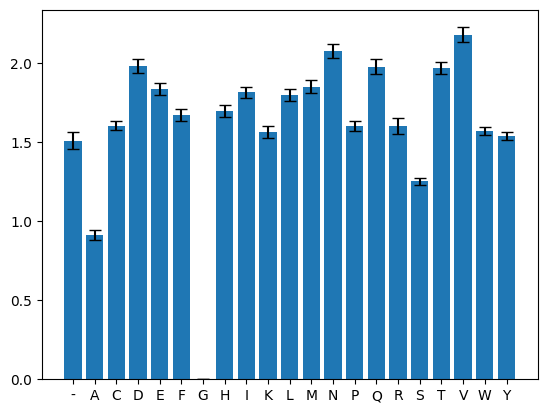

In [21]:
plt.bar(
    np.arange(21),
    np.mean(comp_ddes_list, axis=0),
    yerr=np.std(comp_ddes_list, axis=0) / np.sqrt(10),
    capsize=4
)
plt.xticks(ticks=np.arange(21), labels="-ACDEFGHIKLMNPQRSTVWY")
plt.show()

../models/SectorShuffling_SubAln0_Step00_noshuffle/SectorShuffling_SubAln0_Step00_noshuffle_ModelSBM_N_chains256_N_iter1000_Param_initzero_k_MCMC10000_lambda_J0_lambda_h0_m1_theta0.15_N_Av10_R0.npy


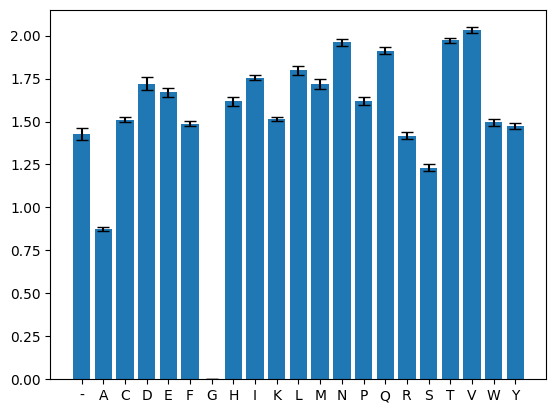

../models/SectorShuffling_SubAln1_Step00_noshuffle/SectorShuffling_SubAln1_Step00_noshuffle_ModelSBM_N_chains256_N_iter1000_Param_initzero_k_MCMC10000_lambda_J0_lambda_h0_m1_theta0.15_N_Av10_R0.npy


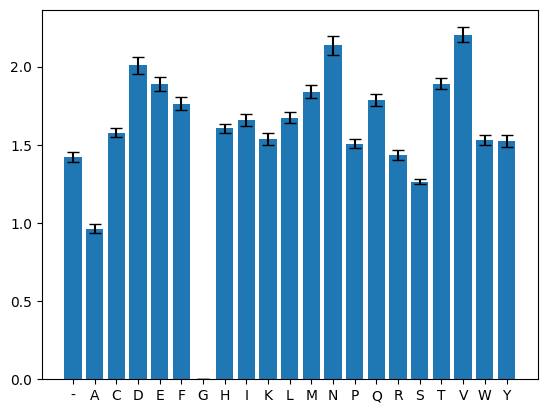

../models/SectorShuffling_SubAln2_Step00_noshuffle/SectorShuffling_SubAln2_Step00_noshuffle_ModelSBM_N_chains256_N_iter1000_Param_initzero_k_MCMC10000_lambda_J0_lambda_h0_m1_theta0.15_N_Av10_R0.npy


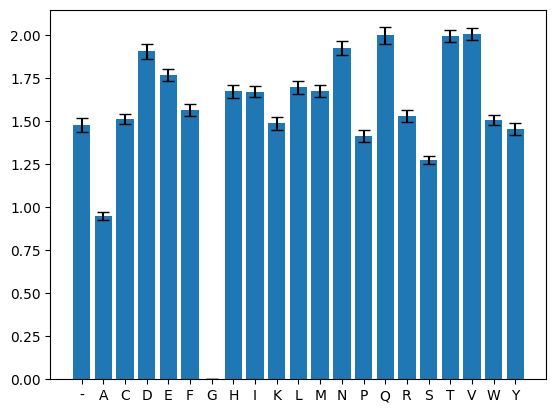

../models/SectorShuffling_SubAln3_Step00_noshuffle/SectorShuffling_SubAln3_Step00_noshuffle_ModelSBM_N_chains256_N_iter1000_Param_initzero_k_MCMC10000_lambda_J0_lambda_h0_m1_theta0.15_N_Av10_R0.npy


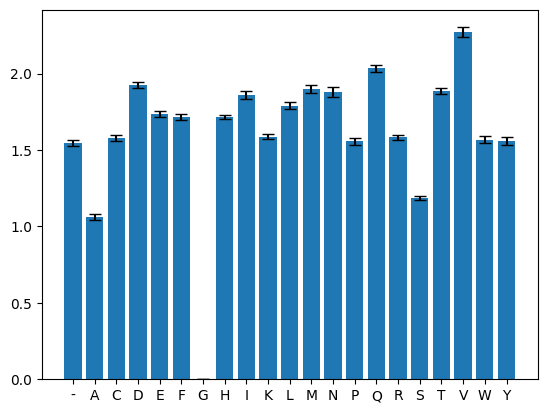

../models/SectorShuffling_SubAln4_Step00_noshuffle/SectorShuffling_SubAln4_Step00_noshuffle_ModelSBM_N_chains256_N_iter1000_Param_initzero_k_MCMC10000_lambda_J0_lambda_h0_m1_theta0.15_N_Av10_R0.npy


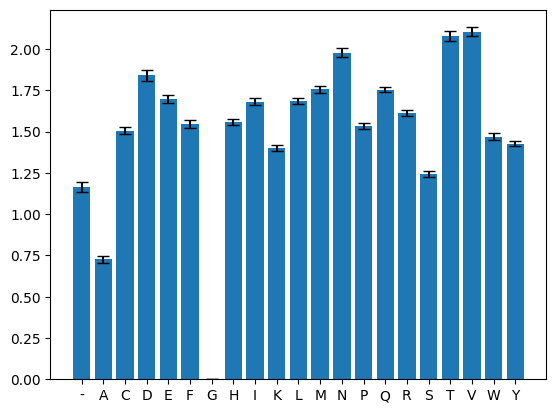

../models/SectorShuffling_SubAln5_Step00_noshuffle/SectorShuffling_SubAln5_Step00_noshuffle_ModelSBM_N_chains256_N_iter1000_Param_initzero_k_MCMC10000_lambda_J0_lambda_h0_m1_theta0.15_N_Av10_R0.npy


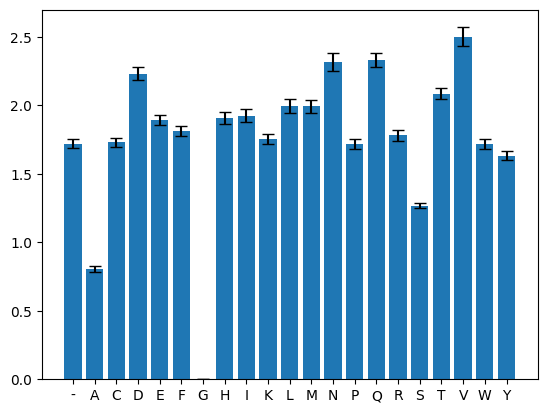

../models/SectorShuffling_SubAln6_Step00_noshuffle/SectorShuffling_SubAln6_Step00_noshuffle_ModelSBM_N_chains256_N_iter1000_Param_initzero_k_MCMC10000_lambda_J0_lambda_h0_m1_theta0.15_N_Av10_R0.npy


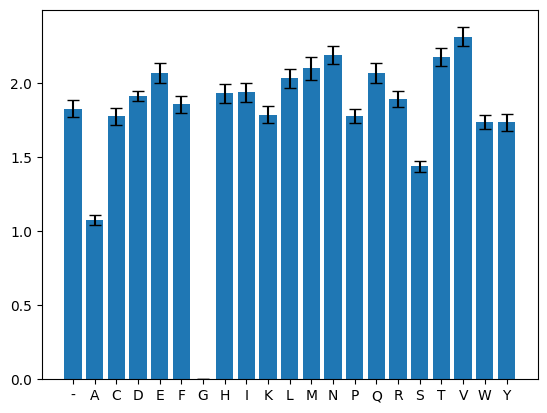

../models/SectorShuffling_SubAln7_Step00_noshuffle/SectorShuffling_SubAln7_Step00_noshuffle_ModelSBM_N_chains256_N_iter1000_Param_initzero_k_MCMC10000_lambda_J0_lambda_h0_m1_theta0.15_N_Av10_R0.npy


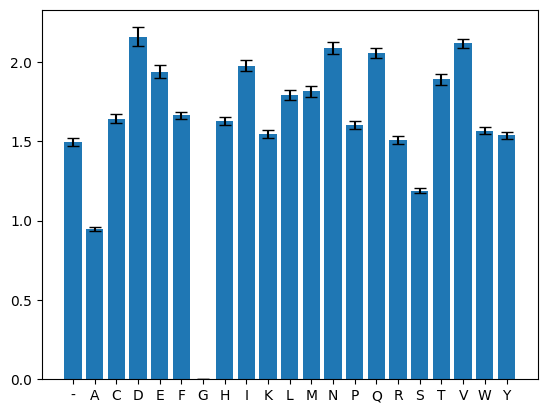

../models/SectorShuffling_SubAln8_Step00_noshuffle/SectorShuffling_SubAln8_Step00_noshuffle_ModelSBM_N_chains256_N_iter1000_Param_initzero_k_MCMC10000_lambda_J0_lambda_h0_m1_theta0.15_N_Av10_R0.npy


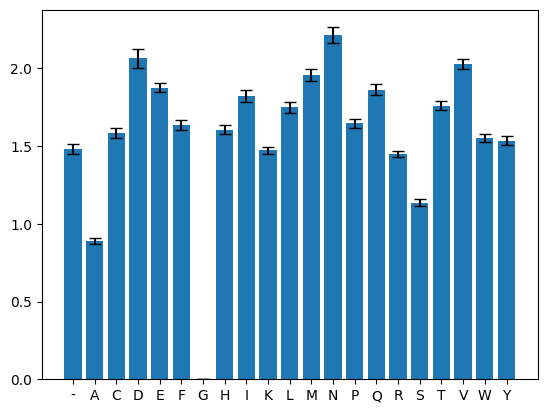

../models/SectorShuffling_SubAln9_Step00_noshuffle/SectorShuffling_SubAln9_Step00_noshuffle_ModelSBM_N_chains256_N_iter1000_Param_initzero_k_MCMC10000_lambda_J0_lambda_h0_m1_theta0.15_N_Av10_R0.npy


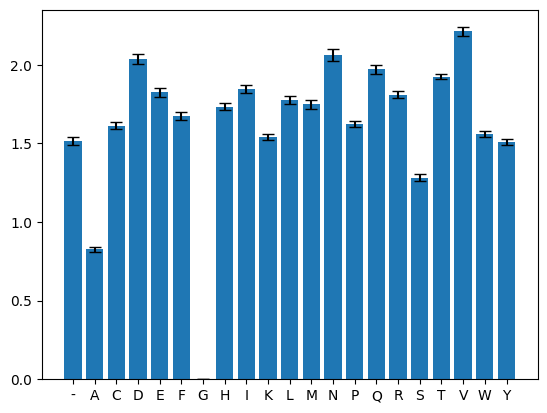

In [8]:
for f in df.loc[0, :].model_file:
    print(f)
    plt.figure()
    model = np.load(f, allow_pickle=True).item()
    Js_for_paramset = []
    for W_all in model["W_all"]:
        J, h = ut.Jw(W_all, q=21)
        Js_for_paramset.append(np.abs(compensatory_ddes(J).ravel()))
    plt.bar(
        np.arange(21),
        np.mean(Js_for_paramset, axis=0),
        yerr=np.std(Js_for_paramset, axis=0) / np.sqrt(10),
        capsize=4
    )
    plt.xticks(ticks=np.arange(21), labels="-ACDEFGHIKLMNPQRSTVWY")
    plt.show()

In [9]:
df.index

MultiIndex([( 0, 0),
            ( 0, 1),
            ( 0, 2),
            ( 0, 3),
            ( 0, 4),
            ( 0, 5),
            ( 0, 6),
            ( 0, 7),
            ( 0, 8),
            ( 0, 9),
            (10, 0),
            (10, 1),
            (10, 2),
            (10, 3),
            (10, 4),
            (10, 5),
            (10, 6),
            (10, 7),
            (10, 8),
            (10, 9),
            (18, 0),
            (18, 1),
            (18, 2),
            (18, 3),
            (18, 4),
            (18, 5),
            (18, 6),
            (18, 7),
            (18, 8),
            (18, 9),
            (19, 0),
            (19, 1),
            (19, 2),
            (19, 3),
            (19, 4),
            (19, 5),
            (19, 6),
            (19, 7),
            (19, 8),
            (19, 9),
            (20, 0),
            (20, 1),
            (20, 2),
            (20, 3),
            (20, 4),
            (20, 5),
            (20, 6),
            (

../models/SectorShuffling_SubAln0_Step22_Col239/SectorShuffling_SubAln0_Step22_Col239_ModelSBM_N_chains256_N_iter1000_Param_initzero_k_MCMC10000_lambda_J0_lambda_h0_m1_theta0.15_N_Av10_R0.npy


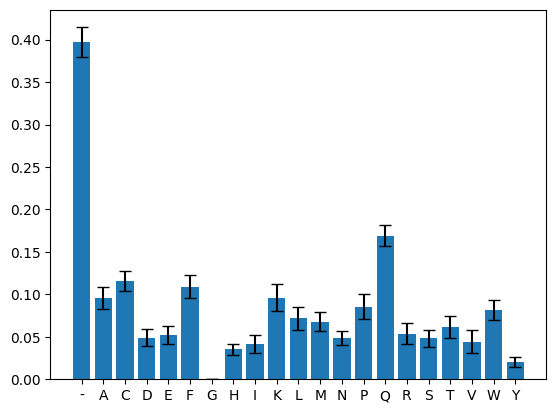

In [19]:
for f in df.loc[22, :].model_file:
    print(f)
    plt.figure()
    model = np.load(f, allow_pickle=True).item()
    Js_for_paramset = []
    for W_all in model["W_all"]:
        J, h = ut.Jw(W_all, q=21)
        Js_for_paramset.append(np.abs(compensatory_ddes(J).ravel()))
    plt.bar(
        np.arange(21),
        np.mean(Js_for_paramset, axis=0),
        yerr=np.std(Js_for_paramset, axis=0) / np.sqrt(10),
        capsize=4
    )
    plt.xticks(ticks=np.arange(21), labels="-ACDEFGHIKLMNPQRSTVWY")
    plt.show()
    break